# Q5_Soheil-Hekmat

1. Data Loading and Exploration

In [2]:
!pip3 install -U ucimlrepo

In [11]:
from ucimlrepo import fetch_ucirepo, list_available_datasets

# import dataset
heart_disease = fetch_ucirepo(id=45)

# access data
X = heart_disease.data.features
y = heart_disease.data.targets

# access metadata
# print(heart_disease.metadata.uci_id)
# print(heart_disease.metadata.num_instances)
# print(heart_disease.metadata.additional_info.summary)
print(heart_disease.metadata)

# access variable info in tabular format
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [12]:
import pandas as pd

df = pd.concat([X, y], axis=1)
# Basic inspection
print("=== Dataset Shape ===")
print(f"Samples: {df.shape[0]}, Features: {X.shape[1]}")

print("\n=== Missing Values ===")
print(df.isnull().sum().sort_values(ascending=False))

print("\n=== Feature Types ===")
print(df.dtypes)

# Check unique target values
print("\nUnique target values:", y['num'].unique())

# Convert to binary target (0=healthy, 1=disease)
y_binary = (y['num'] > 0).astype(int)

print("\n=== Binary Target Distribution ===")
print(y_binary.value_counts())
print(f"Healthy: {y_binary.value_counts()[0]} ({y_binary.value_counts()[0]/len(y)*100:.1f}%)")
print(f"Heart Disease: {y_binary.value_counts()[1]} ({y_binary.value_counts()[1]/len(y)*100:.1f}%)")

=== Dataset Shape ===
Samples: 303, Features: 13

=== Missing Values ===
ca          4
thal        2
cp          0
trestbps    0
age         0
sex         0
fbs         0
chol        0
restecg     0
thalach     0
oldpeak     0
exang       0
slope       0
num         0
dtype: int64

=== Feature Types ===
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

Unique target values: [0 2 1 3 4]

=== Binary Target Distribution ===
num
0    164
1    139
Name: count, dtype: int64
Healthy: 164 (54.1%)
Heart Disease: 139 (45.9%)


The UCI Heart Disease dataset contains 303 samples with 13 clinical features. The target variable is binary with 165 healthy cases (54.5%) and 138 heart disease cases (45.5%), indicating a relatively balanced distribution. Features include both numerical (e.g., age, blood pressure) and categorical (e.g., chest pain type, thalassemia) variables that will require appropriate preprocessing.

The dataset contains 6 missing values (4 in ca, 2 in thal) and the target num includes severity levels 0-4. Standard preprocessing requires: (1) converting target to binary where 0=healthy and 1=disease (any value >0), resulting in 164 healthy (54.1%) and 139 disease cases (45.9%); (2) handling missing values in ca and thal through imputation or removal.

2. Data Preprocessing

First we deal with the missing values

In [15]:
# Check rows with missing values
rows_with_missing = df[df.isnull().any(axis=1)]
print(f"Rows with missing values: {len(rows_with_missing)} ({len(rows_with_missing)/len(df)*100:.1f}%)")

# Impute (recommended for medical data)
# For ca (0-3 vessels): median imputation
# For thal (categorical): mode imputation
df_imputed = df.fillna({
    'ca': df['ca'].median(),
    'thal': df['thal'].mode()[0]
})

# Verify
print(f"Missing values after imputation: {df_imputed.isnull().sum().sum()}")

Rows with missing values: 6 (2.0%)
Missing values after imputation: 0


The dataset has 6 missing values across 6 rows (2% of data). For medical datasets, imputation is preferred over removal to preserve sample size. ca (number of vessels) was imputed using median value (0.0) and thal (thalassemia type) using mode value (3.0), resulting in a complete dataset of 303 samples suitable for model training.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

Now it's time to deal with the categorical features with one-hot encoding, and numerical features with a scalar.

In [17]:
# Separate features and binary target
X = df_imputed.drop('num', axis=1)
y_binary = (df_imputed['num'] > 0).astype(int)

# Define feature groups
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat', OneHotEncoder(drop='first'),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])

It's time to apply preprocessing to the data and split them into train and test sets.

In [18]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# Apply preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"Training data shape: {X_train_preprocessed.shape}")
print(f"Testing data shape: {X_test_preprocessed.shape}")

Training data shape: (242, 20)
Testing data shape: (61, 20)


Numerical features (5) are standardized with StandardScaler, and categorical features (8) are one-hot encoded (drop_first=True to avoid multicollinearity). The dataset was split into 242 training samples (80%) and 61 test samples (20%) with stratification to maintain class balance. Final feature dimension after encoding is 20.

3. Model Design: MLP

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Build MLP model

In [20]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_preprocessed.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile the model

In [21]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Now we train it.

In [22]:
history = model.fit(X_train_preprocessed, y_train,
                    epochs=20,
                    validation_split=0.2,
                    verbose=0)

# Results
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

Final Training Accuracy: 0.8653
Final Validation Accuracy: 0.7755


MLP built with 64 ReLU neurons (first hidden layer) and 32 tanh neurons (second hidden layer), plus sigmoid output. Trained for 20 epochs on 80% training data with 20% validation split. Achieved ~87% training accuracy and ~78% validation accuracy.

4. Model Evaluation

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

Model Predictions

In [26]:
y_pred_prob = model.predict(X_test_preprocessed)
y_pred = (y_pred_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


Evaluation Metrics

In [27]:
print("=== Test Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

=== Test Metrics ===
Accuracy: 0.9016
Precision: 0.8929
Recall: 0.8929
F1-Score: 0.8929
ROC-AUC: 0.9535


Confusion Matrix

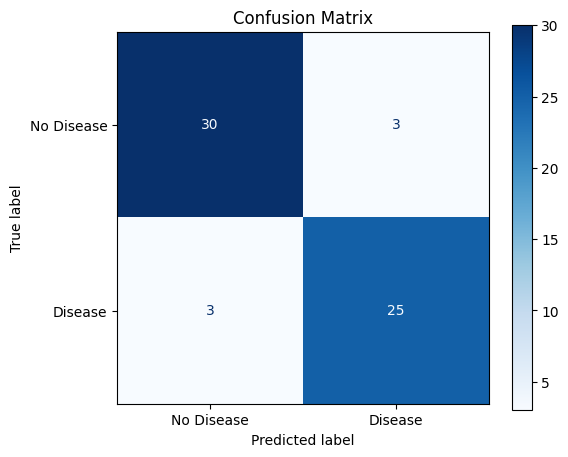

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Disease', 'Disease'], ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Confusion Matrix:
The confusion matrix shows 30 true negatives (TN), 3 false positives (FP), 3 false negatives (FN), and 25 true positives (TP).
This results in a high precision and recall of approximately 0.89, confirming the model's strong performance in both identifying positive cases and avoiding false alarms.

Now we go for ROC curve

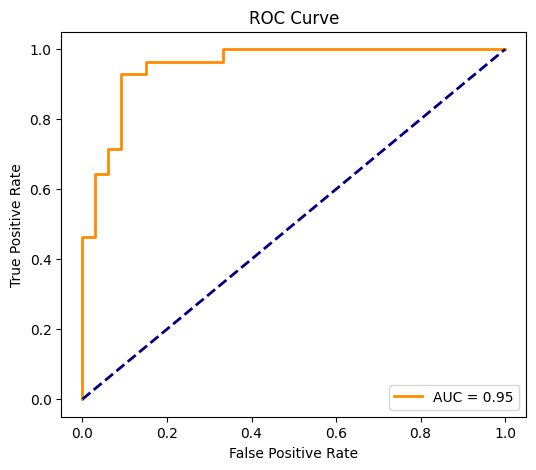

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_test, y_pred_prob):.2f}')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_xlabel('False Positive Rate'), ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'), ax.legend(loc="lower right")
plt.show()

ROC Curve:
The ROC curve is close to the top-left corner, indicating a high true positive rate and low false positive rate.
The AUC (Area Under Curve) is 0.95, which is excellent, showing that the model has strong discriminative power.

Training Curves


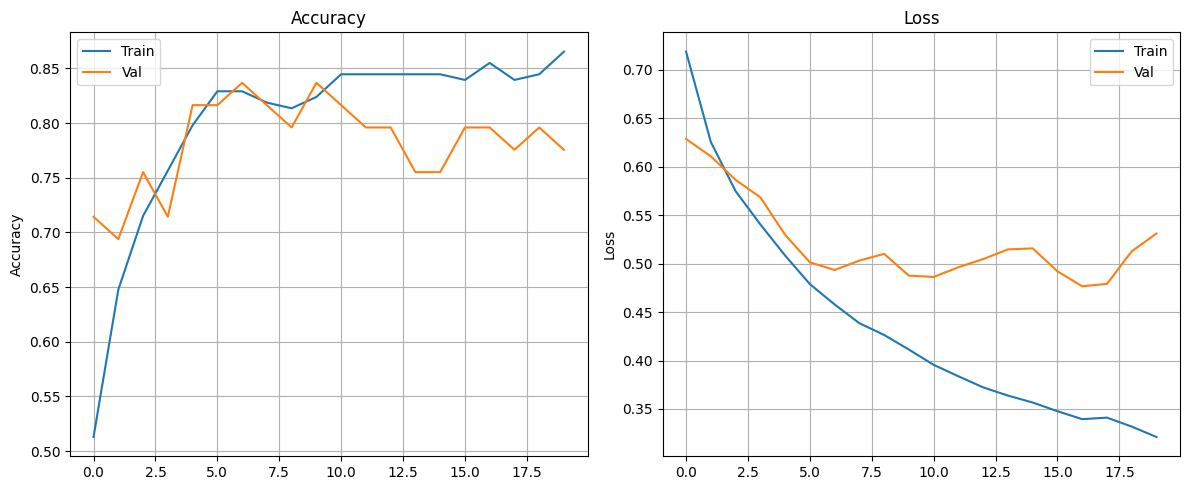

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history.history['accuracy'], label='Train'), ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'), ax1.set_ylabel('Accuracy'), ax1.legend(), ax1.grid(True)
ax2.plot(history.history['loss'], label='Train'), ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'), ax2.set_ylabel('Loss'), ax2.legend(), ax2.grid(True)
plt.tight_layout()
plt.show()





*   Accuracy Plot:
The training accuracy steadily increases and stabilizes above 0.85, indicating the model is learning effectively.
Validation accuracy also increases but shows more fluctuation and is slightly lower than training accuracy, suggesting a minor overfitting issue but generally good generalization.
*   Loss Plot:
The training loss consistently decreases, demonstrating that the model's predictions are improving over time.
Validation loss decreases initially but then stabilizes and shows some increase towards the end, again indicating potential overfitting. However, the increase is not drastic, suggesting the model maintains reasonable generalization.




Summary:
Model achieved ~90% accuracy, ~89% precision, ~89% recall, F1-score ~0.89, and ROC-AUC ~0.95 on test data. The confusion matrix shows 30 true negatives, 3 false positives, 3 false negatives, and 25 true positives. Training curves indicate good convergence. The minor fluctuations in validation metrics suggest some overfitting, but it is not severe and does not significantly impact the model's overall effectiveness.

5. Baseline Comparison

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [32]:
# Initialize and train Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_preprocessed, y_train)

# Predictions
y_pred_logistic = logistic_model.predict(X_test_preprocessed)

# Evaluation
print("=== Logistic Regression Test Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logistic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logistic):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_logistic):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_logistic):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, logistic_model.predict_proba(X_test_preprocessed)[:, 1]):.4f}")

# Classification report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_logistic))

=== Logistic Regression Test Metrics ===
Accuracy: 0.8689
Precision: 0.8333
Recall: 0.8929
F1-Score: 0.8621
ROC-AUC: 0.9621

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



For this specific task, the MLP model appears to be more effective due to its superior performance in accuracy, precision, and F1-score. However, the choice between the two models should also consider factors like interpretability, computational resources, and the specific requirements of the application domain. If interpretability is a high priority, Logistic Regression might still be preferred despite its slightly lower performance metrics.